# Setup

In [1]:
# importing main libs
import numpy as np
import pandas as pd

# libs for plots
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as matcolors
from matplotlib.colors import LightSource
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.tools import mpl_to_plotly

# utils
from dateutil import parser
import pprint as pp

# models
import statsmodels.api as sm

# models (import)
from GAR.partition import retropolated_PCA
from GAR.quantfit import run_quantfit
from GAR.tsfit import run_tsfit, get_cond_quant, select_df_partition
from GAR.scenario import run_scenario, gen_shocked_PCA
from GAR.historical import run_historical
from GAR.segment import run_segment

# # params
# sns.set(style='whitegrid')
# sns.set(rc={'figure.figsize':(4,4)})

In [2]:
# Setting up parameters

# Partition groups
autoregressive = ['real_y_ms_yoy']
financial_conditions = ['consumer_AMD', 'consumer_USD', 
                        'mortgage_AMD', 'mortgage_USD', 
                        'business_AMD', 'business_USD']
policy_conditions = ['tbill', 'gbond','policy_rate']
intermediation = ['loan_to_deposit', 'spread(loan-deposit)', 'spread(loan-tbill)']
housing = ['mortgage_stock_yoy', 'rep_yoy', 'rep_deviation']
leverage = ['credit_to_gdp_gap', 'household_credit_stock_yoy', 'business_credit_stock_yoy', 
            'npl', 'assets_equity']
external_sector = ['exchange_rate', 'net_tr_yoy', 'rus_y_yoy', 'copper_yoy_lag2', 'copper_yoy']

# global parmas
dict_global_params = {'target': 'real_y_ms', 'horizon':4}
dict_groups = {
    'autoregressive': autoregressive, 
    'financial_conditions': financial_conditions, 
    'policy_conditions':policy_conditions,
    'intermediation': intermediation, 
    'housing': housing,
    'leverage': leverage,
    'external_sector':external_sector
}

# assigning a color for each group
color_mapping = {
    'autoregressive':'#1f77b4', 'financial_conditions':'#ff7f0e', 
    'policy_conditions':'#2ca02c', 'intermediation':'#d62728',
    'housing':'#9467bd', 'leverage':'#8c564b', 'external_sector':'#e377c2',
    'real_y_ms':'purple'
}
target_group = {
    'real_y_ms':['real_y_ms']
}
node_colors = {value: color_mapping[key] for key, values in (dict_groups|target_group).items() for value in values}

In [3]:
# importing data and perform pre-processing
df_partition = pd.read_excel('../data/gar_main.xlsm', 'Data')

# interpolate and forward fill missing values
for column in df_partition:
    c = df_partition[column].copy()
    if c.dtype not in [float, np.float64, np.float32]:
        continue
    f_index = c.first_valid_index()
    l_index = c.last_valid_index()
    c.loc[:l_index] = c.loc[:l_index].interpolate(method='linear')
    c.loc[f_index:] = c.loc[f_index:].fillna(method='ffill', limit=None)
    df_partition[column] = c

In [4]:
# imf partition output
imf_data = pd.read_excel('../data/gar_V2.xlsm', 'Output_partitions')
imf_data.dropna(axis=0, how='any', inplace=True)
imf_data.set_index('date', inplace=True)

# Partitioning the input data

In [5]:
choice_columns = [
    'autoregressive', 'policy_conditions', 'intermediation',
    'housing_diff', 'external_sector_diff', 'leverage_L4',
    'external_sector_L1'
]

t_mapping = {
    **{v:v for v in choice_columns},
    'intermediation':'intermediation', 
    'intermediation_detrend':'intermediation_detrend',
    'financial_conditions':'financial_conditions',
    'financial_conditions_diff':'financial_conditions_diff',
    'housing':'housing',
    'housing_diff':'housing_diff',
    'external_sector':'external_sector',
    'external_sector_diff':'external_sector_diff',
    'external_sector_L1':'external_sector_L1',
    'leverage':'leverage',
    'leverage_L4':'leverage_L4'
}

def polytrend(series, level=1):
    index = series.reset_index().index
    z = np.polyfit(index, series, 2)
    p = np.poly1d(z)
    trend = p(index)
    return trend

# MVA
# partition[self.mapping['domestic_macro_MVA']] = partition[self.mapping['domestic_macro']].rolling(window=2).mean()
# partition.drop(columns=self.mapping['domestic_macro'], inplace=True)

class DataTransformer():
    def __init__(self):
        self.choice_columns = choice_columns
        self.mapping = t_mapping
    def transform(self, partition, depvar):
        
        # Lagged
        partition[self.mapping['leverage_L4']] = partition[self.mapping['leverage']].shift(4)
        partition[self.mapping['external_sector_L1']] = partition[self.mapping['external_sector']].shift(1)
        
        # Power
        # partition[reg_long] = partition[reg_short]**(n)
        
        # Diff
        partition[self.mapping['financial_conditions_diff']] = partition[self.mapping['financial_conditions']].diff(4)
        partition[self.mapping['housing_diff']] = partition[self.mapping['housing']].diff(4)
        partition[self.mapping['external_sector_diff']] = partition[self.mapping['external_sector']].diff(4)
        
        # Trend
        trend = polytrend(partition[self.mapping['intermediation']], 2)
        partition[self.mapping['intermediation_detrend']] = partition[self.mapping['intermediation']] - trend
        
         # ChangeRate
        # partition[reg_long] = partition[reg_short].pct_change(n)
        
        # Remove columns not in choice
        selected_columns = [value for key, value in self.mapping.items() if key in self.choice_columns]
        partition = partition[['date', depvar] + selected_columns].copy()
        return partition

# Lets try the transformer
depvar  = dict_global_params['target'] + '_hz_' + str(dict_global_params['horizon'])
transformer = DataTransformer()
macro_data, partition_load, partition_log = retropolated_PCA(df_partition, dict_groups, **dict_global_params)
macro_data = transformer.transform(macro_data, depvar)
display(macro_data)

,date,real_y_ms_hz_4,autoregressive,policy_conditions,intermediation,housing_diff,external_sector_diff,leverage_L4,external_sector_L1
0,2003-03-31,13.508023,1.184524,3.230271,1.603592,NaN,NaN,NaN,NaN
1,2003-06-30,12.249749,1.393630,3.183327,1.776733,NaN,NaN,NaN,0.006946
2,2003-09-30,11.825892,1.435682,2.625615,2.226238,NaN,NaN,NaN,-0.215361
3,2003-12-31,10.458826,1.267188,2.530463,2.162003,NaN,NaN,NaN,-0.265077
4,2004-03-31,10.500432,1.185496,1.267426,2.240881,-1.979681,-0.928649,-1.229727,-0.574728
...,...,...,...,...,...,...,...,...,...
72,2021-03-31,7.764209,-2.004194,0.240673,-0.753179,-0.816599,-0.742778,-0.495928,0.496748
73,2021-06-30,NaN,-1.381457,0.069006,-0.739886,-0.433388,-1.373556,-0.381195,-0.130780
74,2021-09-30,NaN,-0.929113,-0.202292,-0.755305,-0.177271,-1.188943,-0.302718,-0.728951
75,2021-12-31,NaN,0.023901,-0.397200,-0.801171,0.351816,-1.612118,-0.588173,-0.748367


# Quantile regression fit

In [6]:
# quantile regression fit step (2)
quantlist = [0.1, 0.25, 0.5, 0.75, 0.9]
dict_output_quantfit = run_quantfit(macro_data, quantlist=quantlist,
                                    model=sm.QuantReg, **dict_global_params)

In [7]:
qcoef = dict_output_quantfit['qcoef'].reset_index(drop=True)
cond_quant_series = dict_output_quantfit['cond_quant'].reset_index()
cond_quant_series.head()

,date,horizon,tau,realized_value,conditional_quantile_mean,conditional_quantile_mean_se,conditional_quantile_mean_ci_lower,conditional_quantile_mean_ci_upper,conditional_quantile_obs_ci_lower,conditional_quantile_obs_ci_upper
0,2004-03-31,4,0.1,10.500432,3.177019,2.678738,-2.179450,8.533488,-2.540520,8.894558
1,2004-06-30,4,0.1,11.382368,4.298499,2.726533,-1.153541,9.750538,-1.508672,10.105669
2,2004-09-30,4,0.1,11.441260,6.762581,3.096156,0.571434,12.953728,0.256523,13.268639
3,2004-12-31,4,0.1,13.825052,13.825052,3.541313,6.743760,20.906344,6.466846,21.183257
4,2005-03-31,4,0.1,14.508530,15.580191,3.513284,8.554946,22.605437,8.275907,22.884475


# T-skew fit

In [8]:
# tsfit input data
# mode: Free vs Fixed
# fittype: 'T-skew' vs "Asymmetric T"
latest_date = parser.parse('2020-03-31')
fit_params = {
    'fittype': 'T-skew',
    'mode': {'constraint': 'Free', 'value':None},
    'qsmooth': 'None',
    'qsmooth_period':2,
    'plot_mode': True,
    'plot_median': True,
    'plot_mean': False,
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}
# tsfit step (3)
dict_output_tsfit = run_tsfit(latest_date, fit_params, macro_data, qcoef, **dict_global_params)
dfpdf = dict_output_tsfit['dfpdf']
fitted_params = dict(dict_output_tsfit['result'])
print(dfpdf)

     Tskew_PDF_x  Tskew_CDF  Tskew_PDF_y
0        -27.977    0.01638      0.00099
1        -27.927    0.01643      0.00100
2        -27.877    0.01648      0.00100
3        -27.827    0.01653      0.00101
4        -27.777    0.01658      0.00101
..           ...        ...          ...
866       15.323    0.98638      0.00223
867       15.373    0.98649      0.00220
868       15.423    0.98660      0.00218
869       15.473    0.98671      0.00215
870       15.523    0.98681      0.00213

[871 rows x 3 columns]


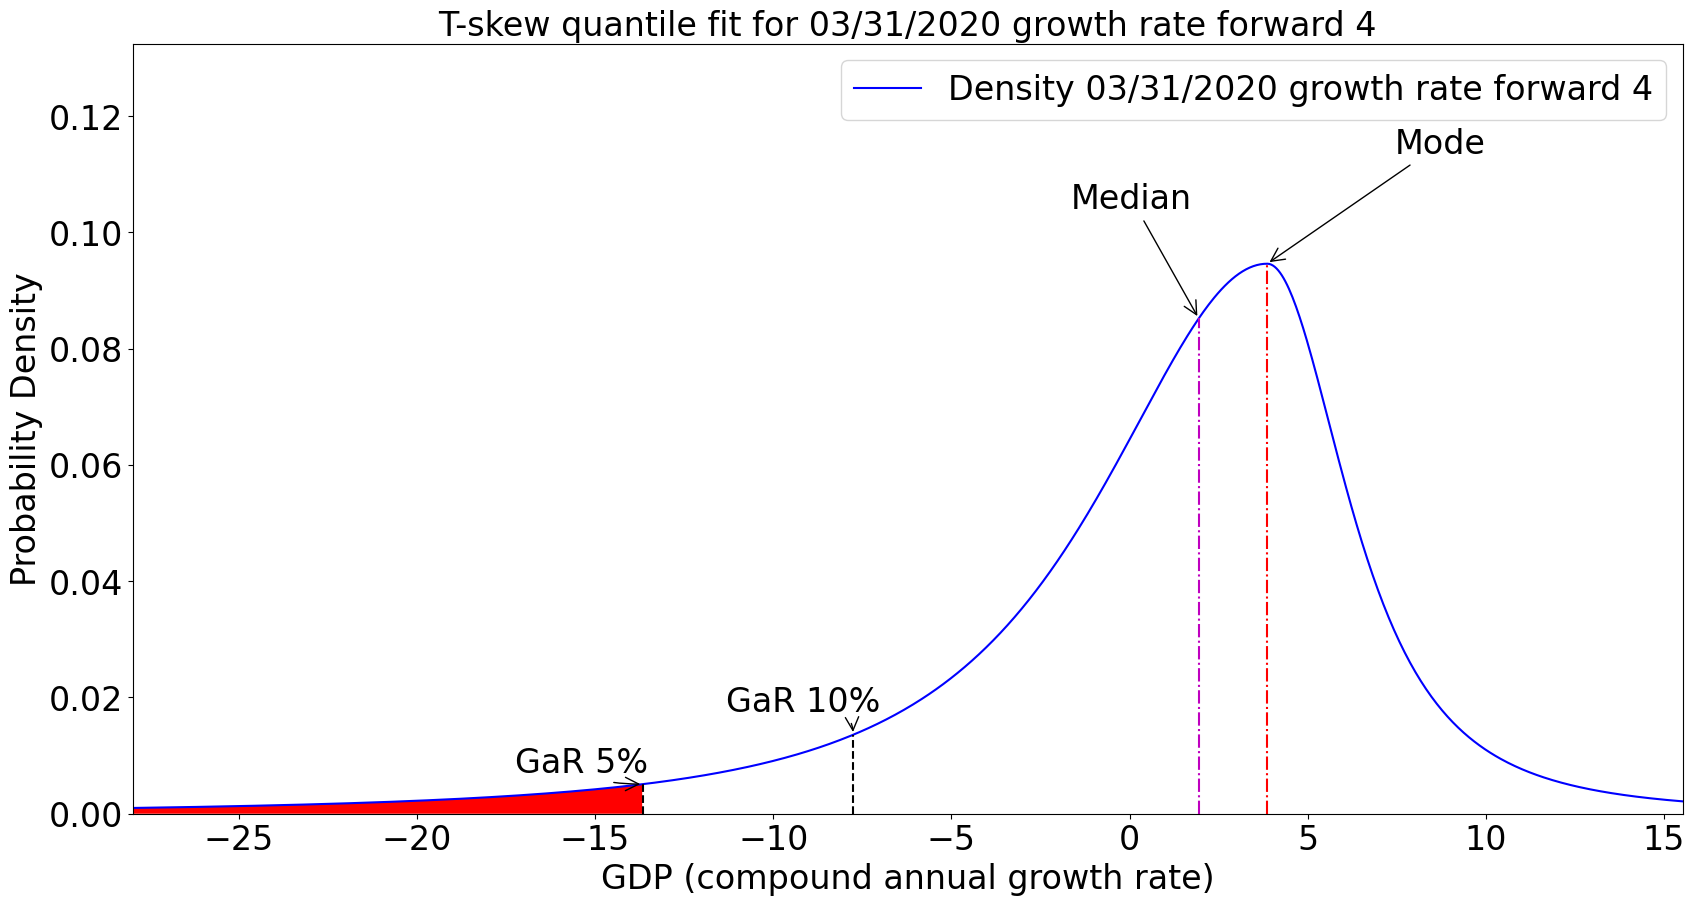

In [9]:
dict_output_tsfit['fig']

# Counterfactual Scenarios Analysis

In [10]:
# scenario input data
latest_date = parser.parse('2020-03-31')
fit_params = {
    'fittype': 'T-skew',
    'mode': {'constraint': 'Free', 'value':None},
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

fit_params_shocked = {
    'fittype': 'T-skew',
    'mode': {'constraint': 'Free', 'value':None},
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}
# shocktype: 'By +/- STD' or 'By +/- percentage' 
shockvars = {
    'policy_rate': {
        'shocktype': 'By +/- STD',
        'shockvalue': 10
    }
}
# generating shocked series
transformer = DataTransformer()
df_shockedvar, df_shockedgrp = gen_shocked_PCA(shockvars, dict_groups, df_partition, 
                                               transformer, **dict_global_params)
df_shockedgrp.columns = df_shockedgrp.columns.str.replace('_shocked', '')

# calculating conditional quantiles
cond_quant = get_cond_quant(latest_date, macro_data, qcoef, **dict_global_params)
cond_quant_shocked = get_cond_quant(latest_date, df_shockedgrp, qcoef, **dict_global_params)

dict_output_scenario = run_scenario(latest_date, cond_quant, cond_quant_shocked, 
                                    fit_params, fit_params_shocked, **dict_global_params)

In [11]:
df_shockedvar.loc[latest_date]

policy_rate            0.052500
policy_rate_shocked    0.221439
Name: 2020-03-31 00:00:00, dtype: float64

In [12]:
print('Results')
print(pd.DataFrame(dict_output_scenario['res']))

Results
                  0                    1                    2
0                           Before shock          After shock
1     Date of input  2020-03-31 00:00:00  2020-03-31 00:00:00
2   Horizon forward                    4                    4
3  Conditional mode               3.8637               3.9957
4             GaR5%           -13.663654           -12.913654
5            GaR10%            -7.763654            -7.213654
6          Skewness                0.693               0.6928
7             Scale               3.4996                3.374


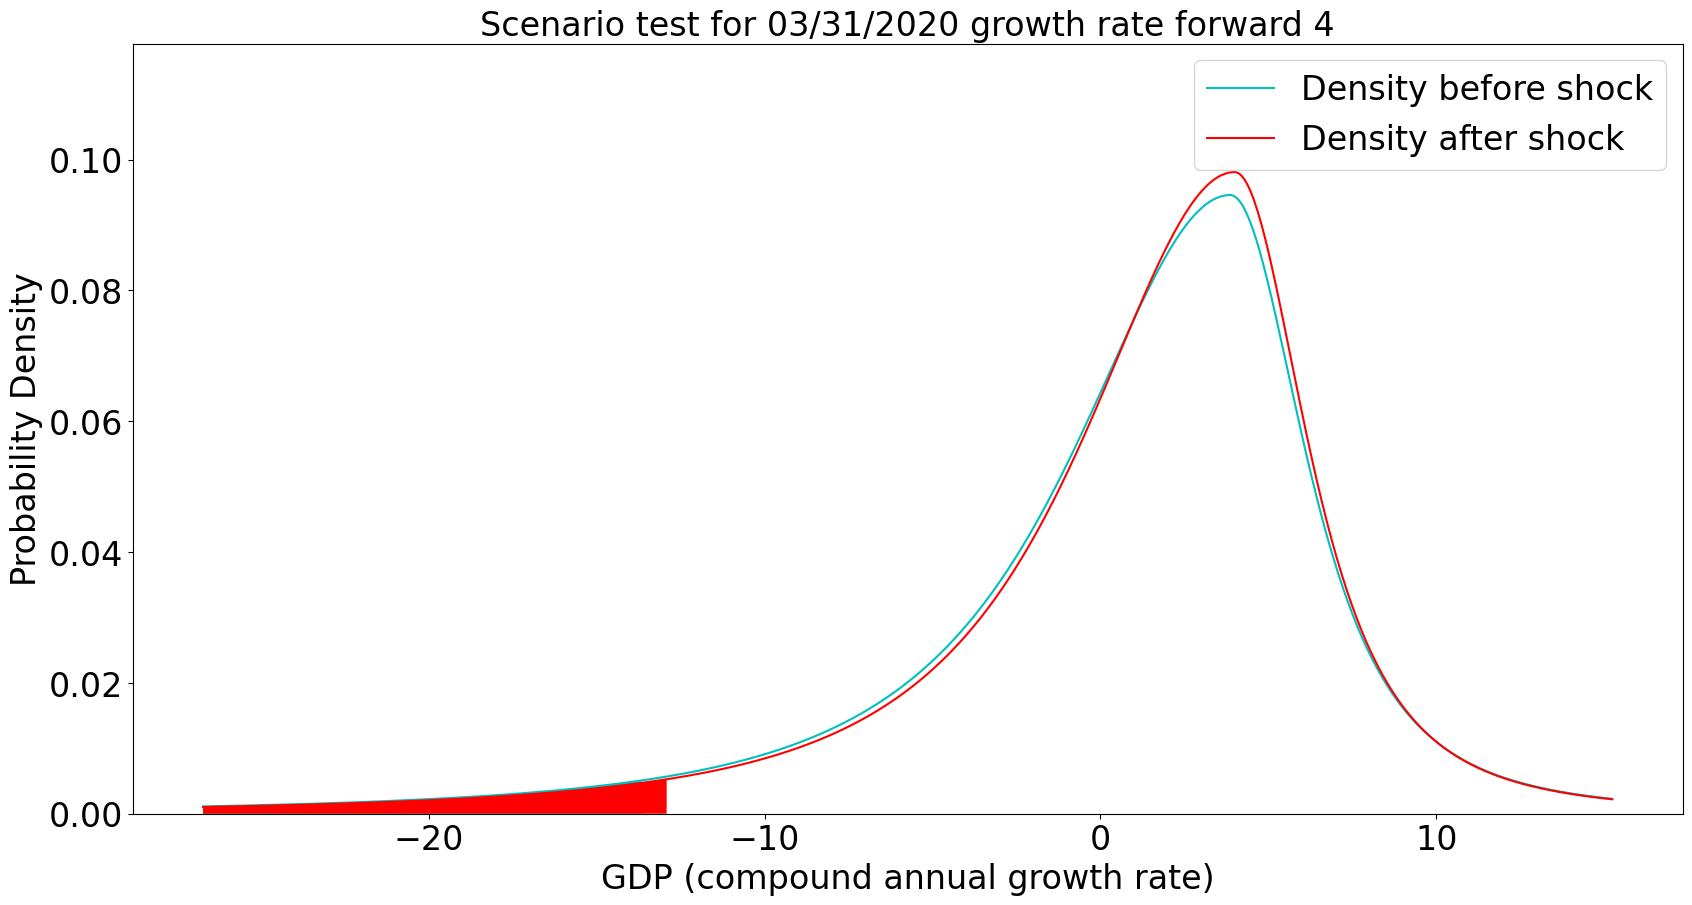

In [13]:
dict_output_scenario['fig']

# Historical dist

In [14]:
# mode: Free vs Fixed
# fittype: 'T-skew' vs "Asymmetric T"
# qsmooth: 'None' vs 'Median' vs 'Mean'
hist_fit_params = {
    'fittype': 'T-skew',
    'mode': {'constraint': 'Free', 'value':None},
    'qsmooth': 'Mean',
    'qsmooth_period': 4,
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

dict_input_historical = {
    'start_date': parser.parse('2003-03-31'),
    'end_date': parser.parse('2022-03-31'),
    'time_inc': 1,
    'fit_params': hist_fit_params,
    **dict_global_params
}
dict_output_historical = run_historical(dict_input_historical, macro_data, qcoef)

In [15]:
hist_sim_data = dict_output_historical['data']
hist_sim_data.head()

,location,scale,skew,dfpdf,var10%,var25%,var50%,var75%,var90%,var5%
2004-03-31,2.204680,3.7566,0.4936,Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,-11.231463,-1.952402,3.885192,7.556435,9.754377,-20.795887
2004-06-30,3.667168,2.6608,0.4622,Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,-5.223456,1.853098,6.276132,9.023718,10.590456,-12.534843
2004-09-30,5.614266,1.9122,0.4535,Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,-0.281006,4.913716,8.154981,10.161979,11.292986,-5.651460
2004-12-31,11.330919,1.0906,0.4939,Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,6.696668,9.388676,11.082367,12.147654,12.785758,3.921937
2005-03-31,13.282947,0.9963,0.6716,Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,9.776739,11.499079,12.634963,13.422670,14.107313,8.030644


In [16]:
# dict_output_historical['figs']['res']

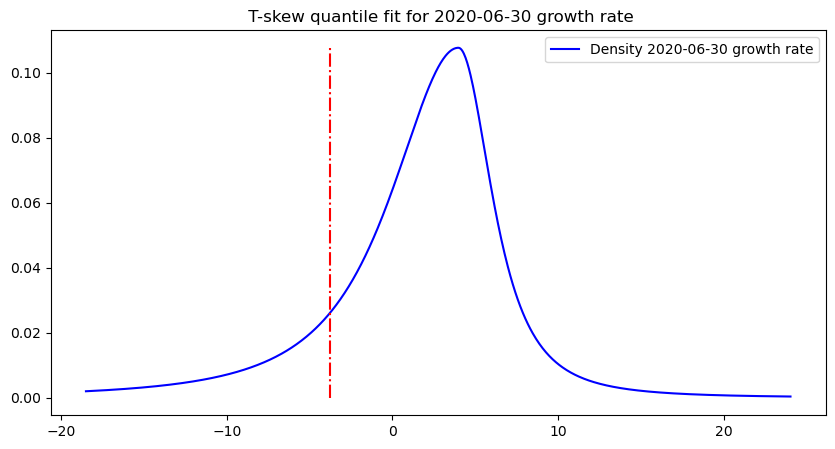

In [17]:
dict_output_historical['charts'][-1]

# Multiple Horizon Projections

In [18]:
# qsmooth_period: int or "auto" (in case of auto its equal to the horizon)
segment_fit_params = {
    'fittype': 'T-skew',
    'mode': {},
    'qsmooth': "None",
    'qsmooth_period': 2,
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

dict_input_segment = {
    'horizonlist': [4, 8, 12, 16],
    'method_growth':'cpd',
    'retropolate':'Yes',
    'partition_groups': dict_groups,
    'transformer':transformer,
    'quantlist':[0.1, 0.25, 0.5, 0.75, 0.9],
    'fitdate': parser.parse('6/30/2018'),
    'fit_params': segment_fit_params,
    'fitconstrainlist': ['Free']*4,
    'fitconstrainvalues': [None]*4,
    **dict_global_params
}
dict_output_segment = run_segment(dict_input_segment, df_partition, model=sm.QuantReg)

/Users/victoryerz/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning:

Maximum number of iterations (1000) reached.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


In [19]:
pd.DataFrame(dict_output_segment['res'])

,horizon,df_quantcoef,olsmean,cond_quant,tsfit,dfpdf,loc
0,4,variable ho...,3.083864,"{0.1: -0.6241787710521818, 0.25: -0.4671697766...","{'loc': 4.6441, 'df': 2, 'scale': 2.7229, 'ske...",Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,4.6441
1,8,variable ho...,1.373040,"{0.1: -1.3090591916780376, 0.25: -0.3580015091...","{'loc': 1.0285, 'df': 2, 'scale': 2.2553, 'ske...",Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,1.0285
2,12,variable ho...,0.423643,"{0.1: -0.5718478891472096, 0.25: -0.6174252492...","{'loc': -0.5875, 'df': 2, 'scale': 1.1128, 'sk...",Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,-0.5875
3,16,variable ho...,0.052014,"{0.1: -2.364620862448931, 0.25: 0.914522670695...","{'loc': 1.8644, 'df': 2, 'scale': 0.8135, 'ske...",Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,1.8644


In [20]:
dict_output_segment['tails']

[['Forward horizon', 4, 8, 12, 16],
 ['Conditional mode', 4.6441, 1.0285, -0.5875, 1.8644],
 ['Conditional median', 4.1972, 1.8811, 0.7886, 1.1757],
 ['Conditional mean', 3.755, 2.6985, 1.9517, 0.564],
 ['GaR5%', -4.857, -3.2369, -1.3941, -3.2462],
 ['GaR10%', -1.5595, -1.618, -0.98, -1.5495],
 ['Growth below 0 probablity', 0.1493, 0.2294, 0.3291, 0.2334]]

In [21]:
dict_output_segment['dfpdf'].head()

,Tskew_PDF_x,Tskew_PDF_y_PROJ1,Tskew_CDF_y_PROJ1,Tskew_PDF_y_PROJ2,Tskew_CDF_y_PROJ2,Tskew_PDF_y_PROJ3,Tskew_CDF_y_PROJ3,Tskew_PDF_y_PROJ4,Tskew_CDF_y_PROJ4
0,-13.086668,0.001712,0.015847,0.000769,0.005553,0.000054,0.000336,0.000846,0.006403
1,-13.036668,0.001726,0.015933,0.000777,0.005592,0.000054,0.000339,0.000854,0.006446
2,-12.986668,0.001740,0.016019,0.000785,0.005631,0.000055,0.000342,0.000862,0.006489
3,-12.936668,0.001754,0.016107,0.000794,0.005670,0.000056,0.000344,0.000871,0.006532
4,-12.886668,0.001768,0.016195,0.000802,0.005710,0.000056,0.000347,0.000880,0.006576


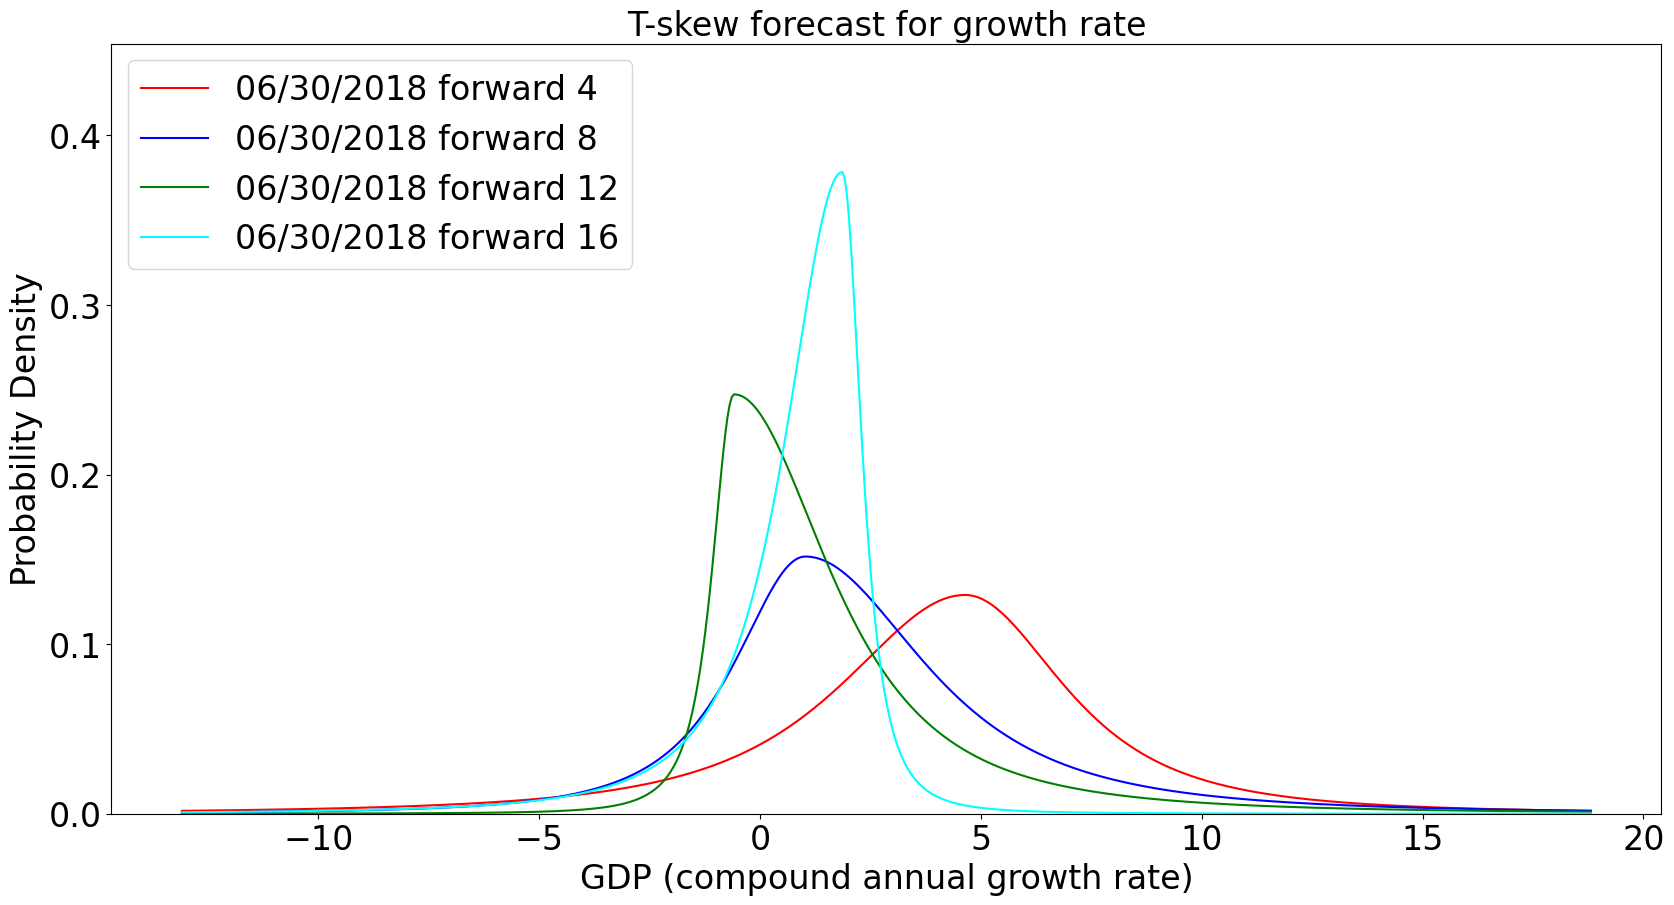

In [22]:
dict_output_segment['fig']

In [23]:
# df_term['error_hz'+str(horizon)]=(df_quantcoef['upper']-df_quantcoef['lower'])/2
# loc=tsfit['loc']/tsfit['scale']
# loc=tsfit['loc']

# Results

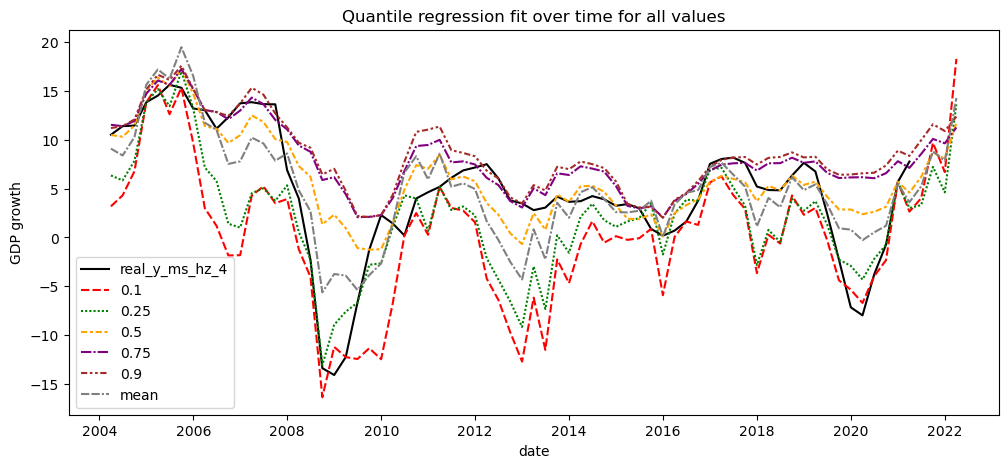

In [24]:
sns.reset_defaults()
qfit_series = cond_quant_series.pivot_table(values='conditional_quantile_mean', index='date', columns='tau')
qfit_series = pd.merge(qfit_series, macro_data[['date','real_y_ms_hz_4']], how='left', on='date')
qfit_series = qfit_series[[qfit_series.columns[-1]] + list(qfit_series.columns[:-1])]
qfit_series = qfit_series.set_index('date')
palette = {
    0.1: 'red',
    0.25: 'green',
    0.5: 'orange',
    0.75: 'purple',
    0.9: 'brown',
    'mean': 'gray',
    'real_y_ms_hz_4': 'black'
}
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=qfit_series, palette=palette, ax=ax)
plt.title('Quantile regression fit over time for all values')
plt.ylabel('GDP growth')
plt.show()

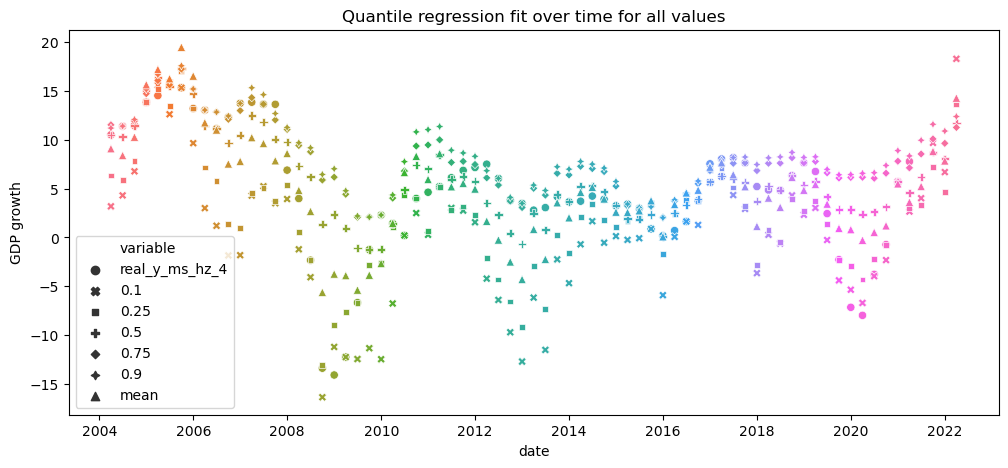

In [25]:
qdist = qfit_series.reset_index().melt(id_vars='date', value_vars=['real_y_ms_hz_4',*quantlist, 'mean'])
fig, ax = plt.subplots(figsize=(12, 5))

sns.scatterplot(data=qdist, x='date', y='value', hue='date', style='variable', legend=True, ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-8:], labels[-8:], frameon=True)
plt.title('Quantile regression fit over time for all values')
plt.ylabel('GDP growth') 
plt.show()

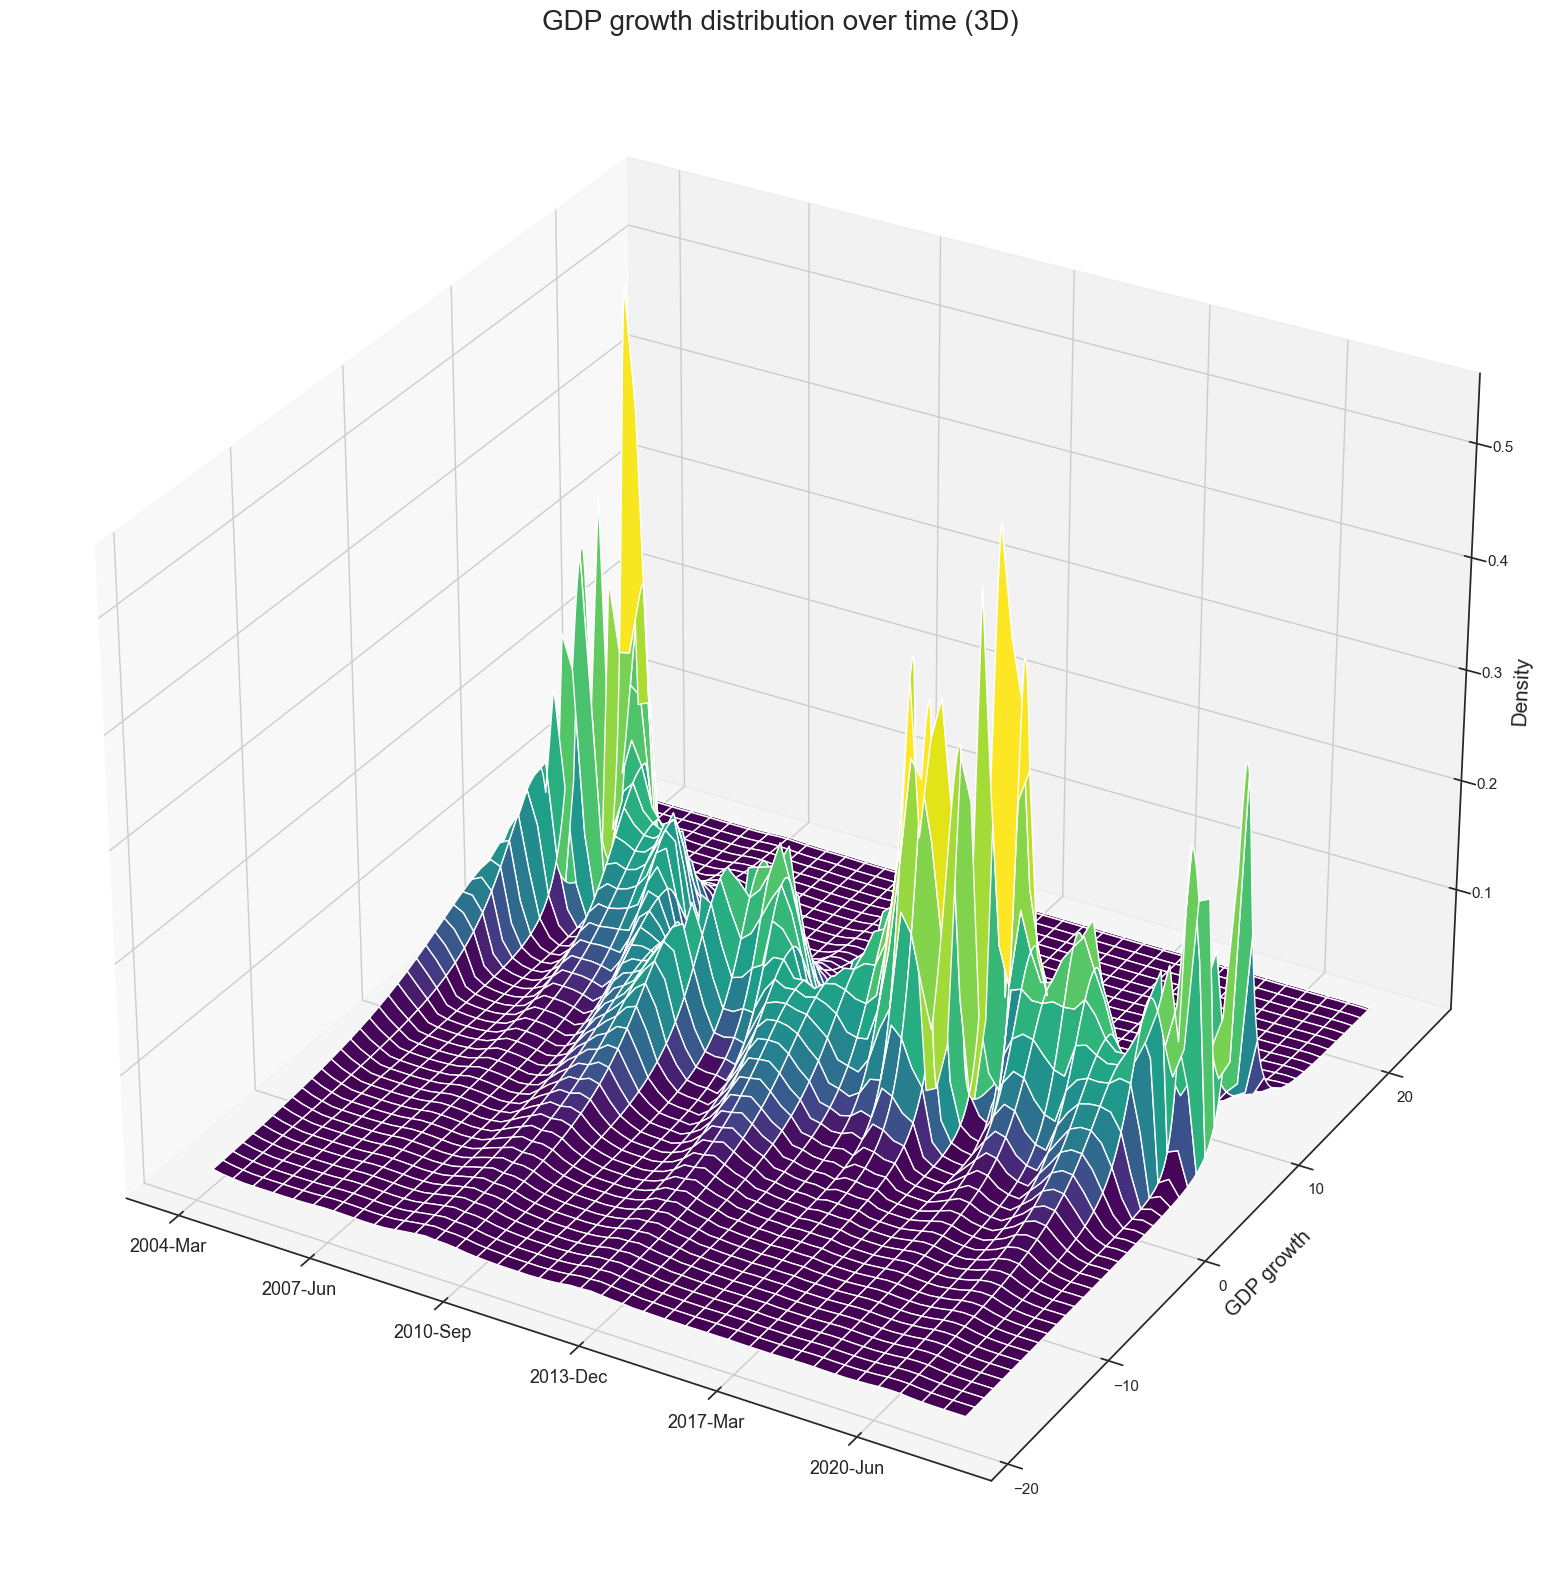

In [26]:
# custom outline
sns.set_theme(style="white", palette='viridis')

# Data preparation
# Tskew vs AsymT
method = 'Tskew'
df_PDF = pd.concat(hist_sim_data['dfpdf'].values, keys=hist_sim_data['dfpdf'].index).reset_index(level=1, drop=True)
df_PDF = df_PDF.reset_index().rename(columns={'index':'date'})
gdp_growth = df_PDF.groupby('date')[method+'_PDF_x'].apply(lambda x: list(x)).apply(lambda x: pd.Series(x))
gdp_density = df_PDF.groupby('date')[method+'_PDF_y'].apply(lambda x: list(x)).apply(lambda x: pd.Series(x))
dates = gdp_growth.index
dates_grid = np.repeat(dates, len(gdp_growth.columns)).to_numpy().reshape(-1, len(gdp_growth.columns))
dates_grid_values = np.repeat(np.arange(len(dates)), len(gdp_growth.columns)).reshape(-1, len(gdp_growth.columns))

# 3D plotting
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(dates_grid_values, gdp_growth, gdp_density, cmap=cm.viridis, 
                norm=matcolors.SymLogNorm(linthresh=0.02, linscale=0.03))
ax.set_xticks(np.arange(len(dates))[0::13])
ax.set_xticklabels(dates[0::13].strftime('%Y-%b'), fontsize=13)
ax.set_ylabel('GDP growth', fontsize=15)
ax.set_zlabel('Density', fontsize=15)
plt.title('GDP growth distribution over time (3D)', fontsize=20)
plt.show()

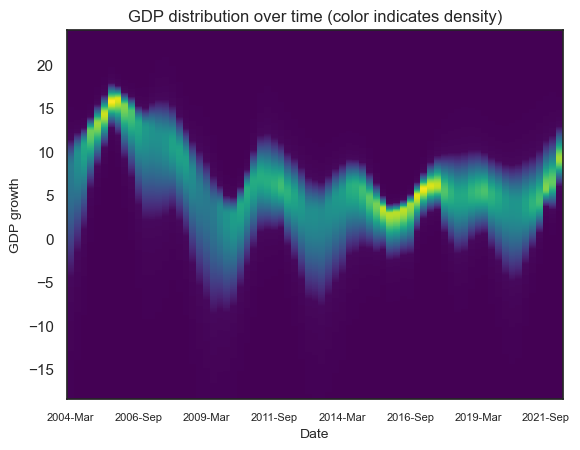

In [27]:
sns.reset_defaults()
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

fig, ax = plt.subplots(1, 1)
ax.pcolormesh(dates_grid_values, gdp_growth, gdp_density, cmap=cm.viridis,
              norm=matcolors.SymLogNorm(linthresh=0.02, linscale=0.03))
ax.set_xticks(np.arange(len(dates))[0::10])
ax.set_xticklabels(dates[0::10].strftime('%Y-%b'), fontsize=8)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('GDP growth', fontsize=10)
plt.title('GDP distribution over time (color indicates density)')
plt.show()

In [34]:
fig = go.Figure(data=[go.Surface(x=dates_grid, y=gdp_growth, z=gdp_density,
                                 surfacecolor=gdp_density, colorscale='viridis',
                                 connectgaps=True, opacity=0.99, showscale=False)])
fig.update_traces(
    contours_z=dict(show=True, usecolormap=True, highlightcolor="limegreen", project_z=True)
)

fig.update_layout(
    template='simple_white',
    title='GDP distribution over time (3D)',
    autosize=False,
    scene=dict(
        camera_eye=dict(x=1.2, y=-1.4, z=0.4),
        xaxis_title='Date',
        yaxis_title='GDP growth',
        zaxis_title='Density'
    ),
    width=1200,
    height=800,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig.write_html('../Results/GDP_dist_interactive_hollow.html')